In [43]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Loading and little preprocessing

In [44]:
# load the Titanic dataset
titanic = pd.read_csv("titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
# drop columns "PassengerId", "Name", "Ticket", "Cabin"
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [46]:
# one-hot encode the "Sex" and "Embarked" columns
titanic = pd.get_dummies(titanic, columns=["Sex", "Embarked"], drop_first=True)
titanic.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [47]:
# check for NaN
titanic.isnull().sum()

Survived        0
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [48]:
# impute missing values in "Age" with the median age
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

# Decision tree model

In [49]:
# separate features and target variable
X = titanic.drop(columns=["Survived"])
y = titanic["Survived"]
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
# train a decision tree classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [51]:
# evaluate the model on the train set
train_accuracy = tree_clf.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.2f}")

Train set accuracy: 0.98


In [52]:
# evaluate the model on the test set
accuracy = tree_clf.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.2f}")

Test set accuracy: 0.78


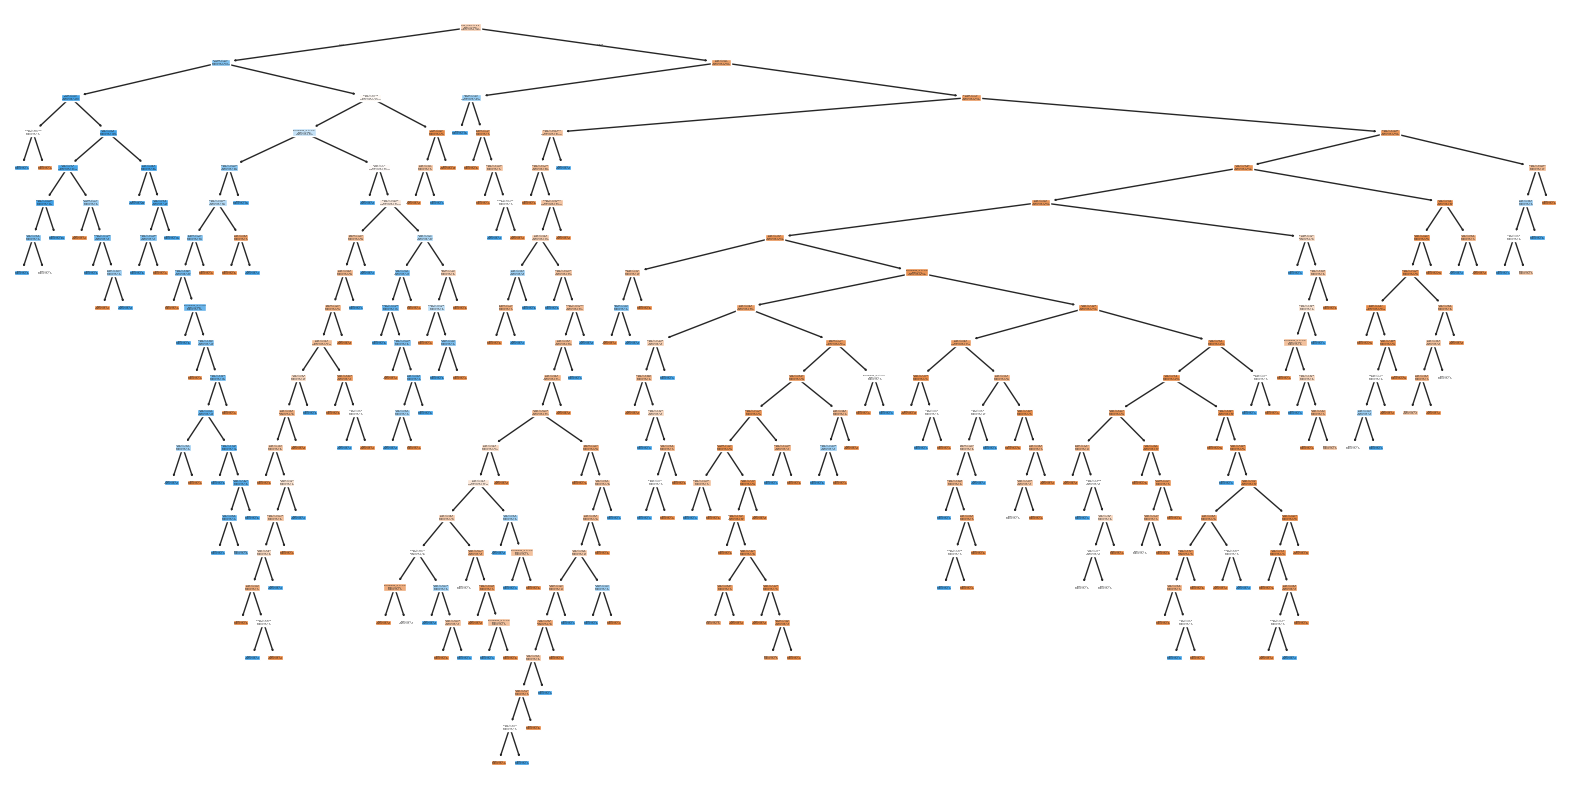

In [53]:
# visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, filled=True, feature_names=X.columns)
plt.show()

In [54]:
# set hyperparameters to control the complexity of the tree
tree_clf_pruned = DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)
tree_clf_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)

In [55]:
# evaluate the pruned tree on the train set
train_accuracy_pruned = tree_clf_pruned.score(X_train, y_train)
print(f"Train set accuracy of pruned tree: {train_accuracy_pruned:.2f}")

Train set accuracy of pruned tree: 0.84


In [56]:
# evaluate the pruned tree on the test set
accuracy_pruned = tree_clf_pruned.score(X_test, y_test)
print(f"Test set accuracy of pruned tree: {accuracy_pruned:.2f}")

Test set accuracy of pruned tree: 0.80


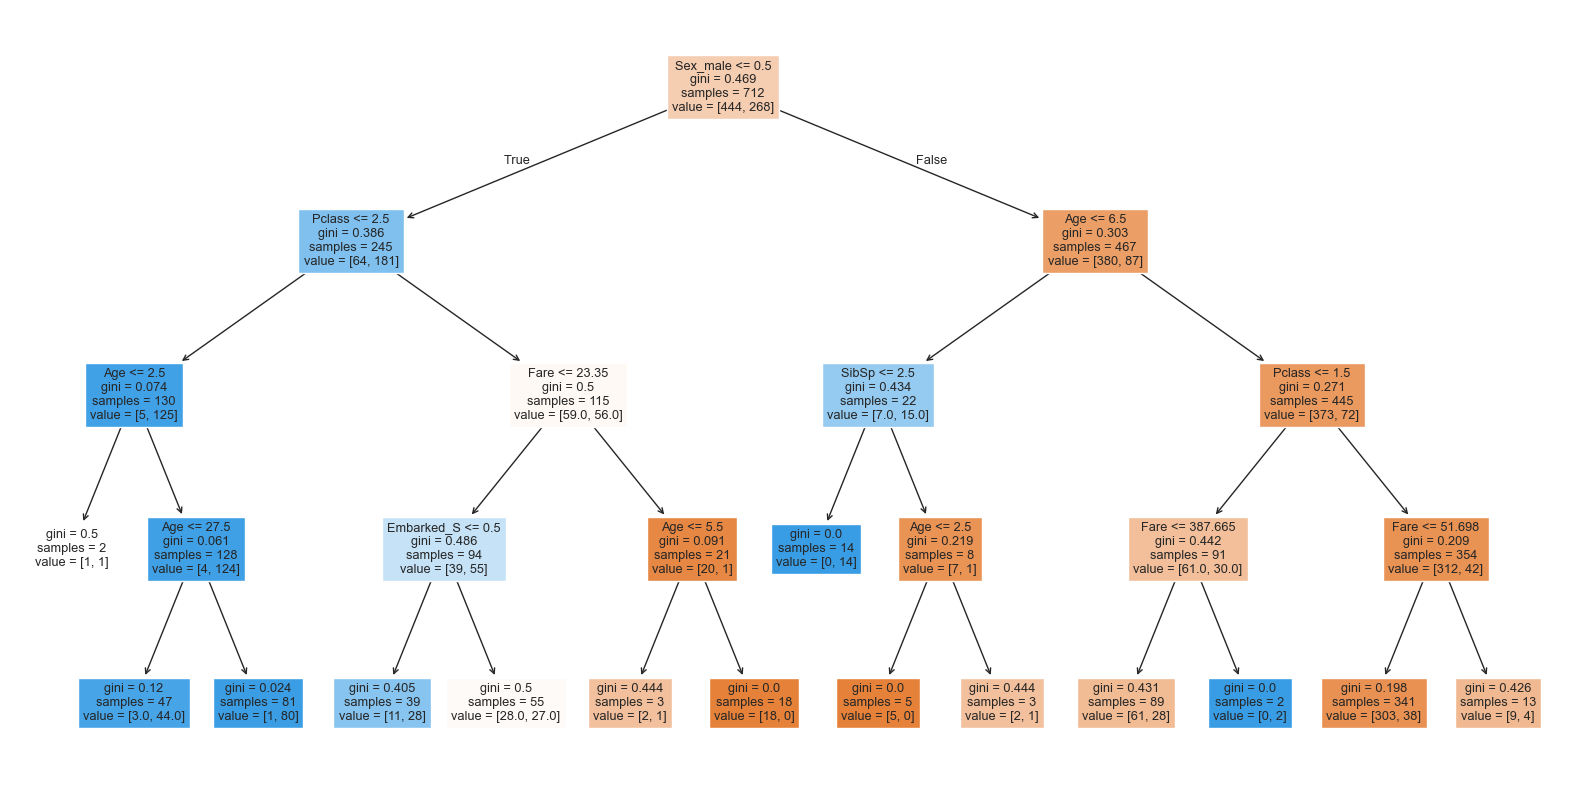

In [57]:
# visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_clf_pruned, filled=True, feature_names=X.columns)
plt.show()

## Random Forest

In [58]:
# train a random forest classifier
n_features = X_train.shape[1]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, max_features=int(np.sqrt(n_features)))
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, max_features=2, random_state=42)

In [59]:
# evaluate the random forest on the train set
train_accuracy_rf = rf_clf.score(X_train, y_train)
print(f"Train set accuracy of random forest: {train_accuracy_rf:.2f}")
# evaluate the random forest on the test set
accuracy_rf = rf_clf.score(X_test, y_test)
print(f"Test set accuracy of random forest: {accuracy_rf:.2f}")

Train set accuracy of random forest: 0.85
Test set accuracy of random forest: 0.82


In [60]:
# feature importance from the random forest
feature_importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)

      Feature  Importance
5    Sex_male    0.504008
0      Pclass    0.149024
4        Fare    0.144369
1         Age    0.088381
2       SibSp    0.050561
7  Embarked_S    0.029015
3       Parch    0.028541
6  Embarked_Q    0.006101


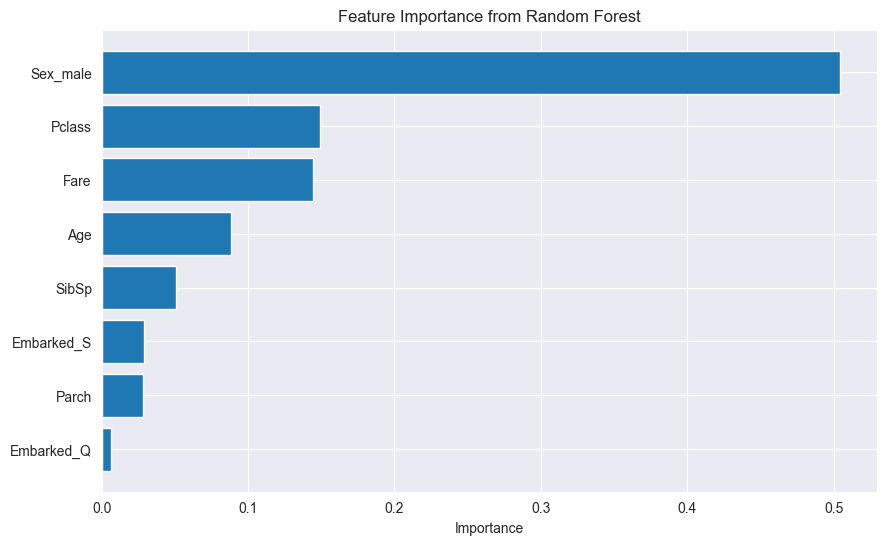

In [61]:
# visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance from Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [62]:
# change hyperparameters of the random forest - max_feature
rf_clf_tuned = RandomForestClassifier(n_estimators=100, max_depth=4, max_features=1, random_state=42)
rf_clf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, max_features=1, random_state=42)

In [63]:
# evaluate the tuned random forest on the train set
train_accuracy_rf_tuned = rf_clf_tuned.score(X_train, y_train)
print(f"Train set accuracy of tuned random forest: {train_accuracy_rf_tuned:.2f}")
# evaluate the tuned random forest on the test set
accuracy_rf_tuned = rf_clf_tuned.score(X_test, y_test)
print(f"Test set accuracy of tuned random forest: {accuracy_rf_tuned:.2f}")

Train set accuracy of tuned random forest: 0.84
Test set accuracy of tuned random forest: 0.82


## Gradient-boosted trees

In [64]:
# train a gradient boosting classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, random_state=42)

In [65]:
# evaluate the gradient boosting classifier on the train set
train_accuracy_gb = gb_clf.score(X_train, y_train)
print(f"Train set accuracy of gradient boosting: {train_accuracy_gb:.2f}")
# evaluate the gradient boosting classifier on the test set
accuracy_gb = gb_clf.score(X_test, y_test)
print(f"Test set accuracy of gradient boosting: {accuracy_gb:.2f}")

Train set accuracy of gradient boosting: 0.93
Test set accuracy of gradient boosting: 0.83


In [67]:
# reduce n_estimators to prevent overfitting
gb_clf_tuned = GradientBoostingClassifier(n_estimators=50, max_depth=4, random_state=42)
gb_clf_tuned.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, n_estimators=50, random_state=42)

In [68]:
# evaluate the tuned gradient boosting classifier on the train set
train_accuracy_gb_tuned = gb_clf_tuned.score(X_train, y_train)
print(f"Train set accuracy of tuned gradient boosting: {train_accuracy_gb_tuned:.2f}")
# evaluate the tuned gradient boosting classifier on the test set
accuracy_gb_tuned = gb_clf_tuned.score(X_test, y_test)
print(f"Test set accuracy of tuned gradient boosting: {accuracy_gb_tuned:.2f}")

Train set accuracy of tuned gradient boosting: 0.90
Test set accuracy of tuned gradient boosting: 0.83
